# DP

Episode 50/5000 | Avg Reward: -118968.89 | Avg Loss: 506.0677 | Eps: 0.2335
  [Target network updated at step 500]
Episode 100/5000 | Avg Reward: -115200.99 | Avg Loss: 33.2885 | Eps: 0.1817
Episode 150/5000 | Avg Reward: -110608.61 | Avg Loss: 46.5028 | Eps: 0.1414
  [Target network updated at step 1000]
Episode 200/5000 | Avg Reward: -120823.28 | Avg Loss: 7.4676 | Eps: 0.1101
Episode 250/5000 | Avg Reward: -127954.92 | Avg Loss: 20.5663 | Eps: 0.0857
  [Target network updated at step 1500]
Episode 300/5000 | Avg Reward: -118778.20 | Avg Loss: 1.7092 | Eps: 0.0667
Episode 350/5000 | Avg Reward: -112003.00 | Avg Loss: 7.1185 | Eps: 0.0519
  [Target network updated at step 2000]
Episode 400/5000 | Avg Reward: -118471.84 | Avg Loss: 0.1643 | Eps: 0.0404
Episode 450/5000 | Avg Reward: -121538.58 | Avg Loss: 2.1752 | Eps: 0.0314
  [Target network updated at step 2500]
Episode 500/5000 | Avg Reward: -135662.36 | Avg Loss: 0.0425 | Eps: 0.0245
Episode 550/5000 | Avg Reward: -140180.65 | Avg

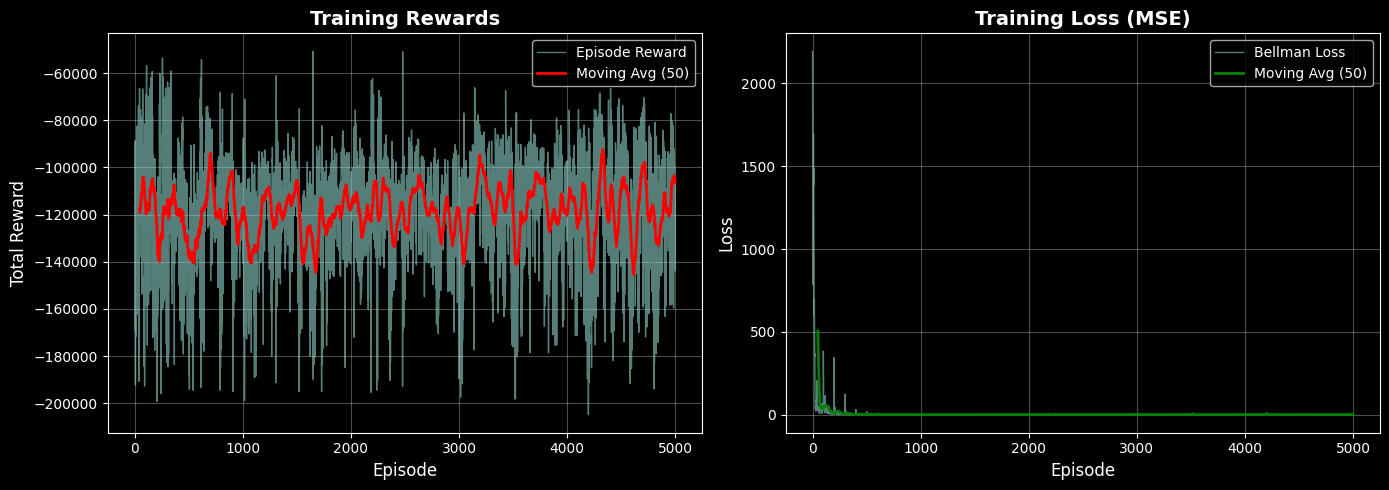

[2/5] Plotting BIS trajectory...


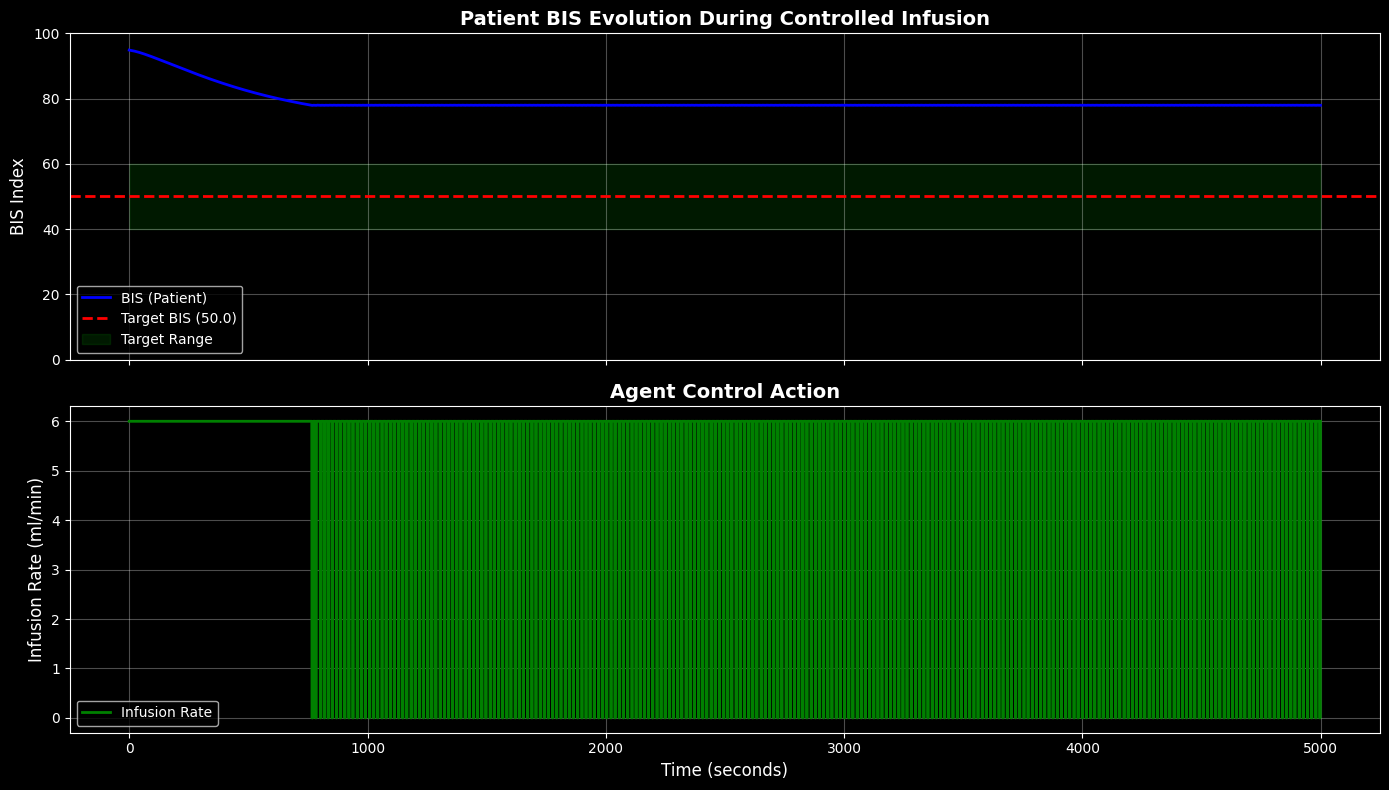

[3/5] Plotting Q-values heatmap...


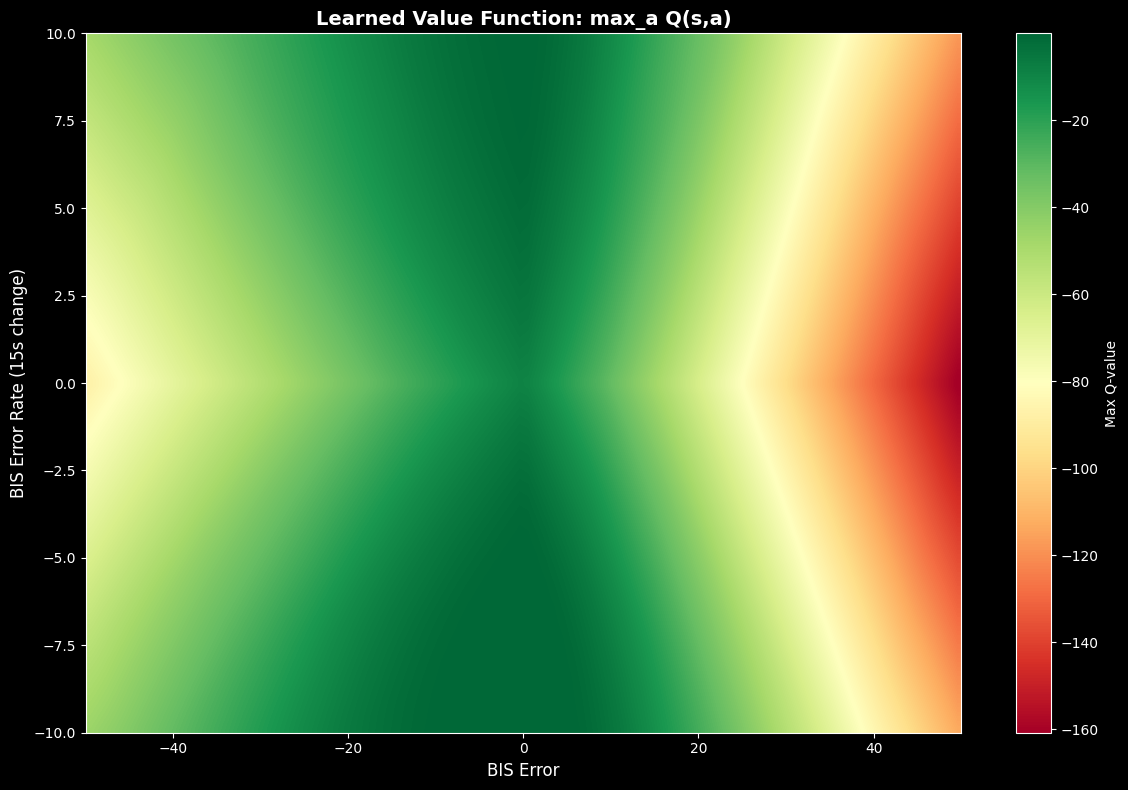

[4/5] Plotting learned policy...


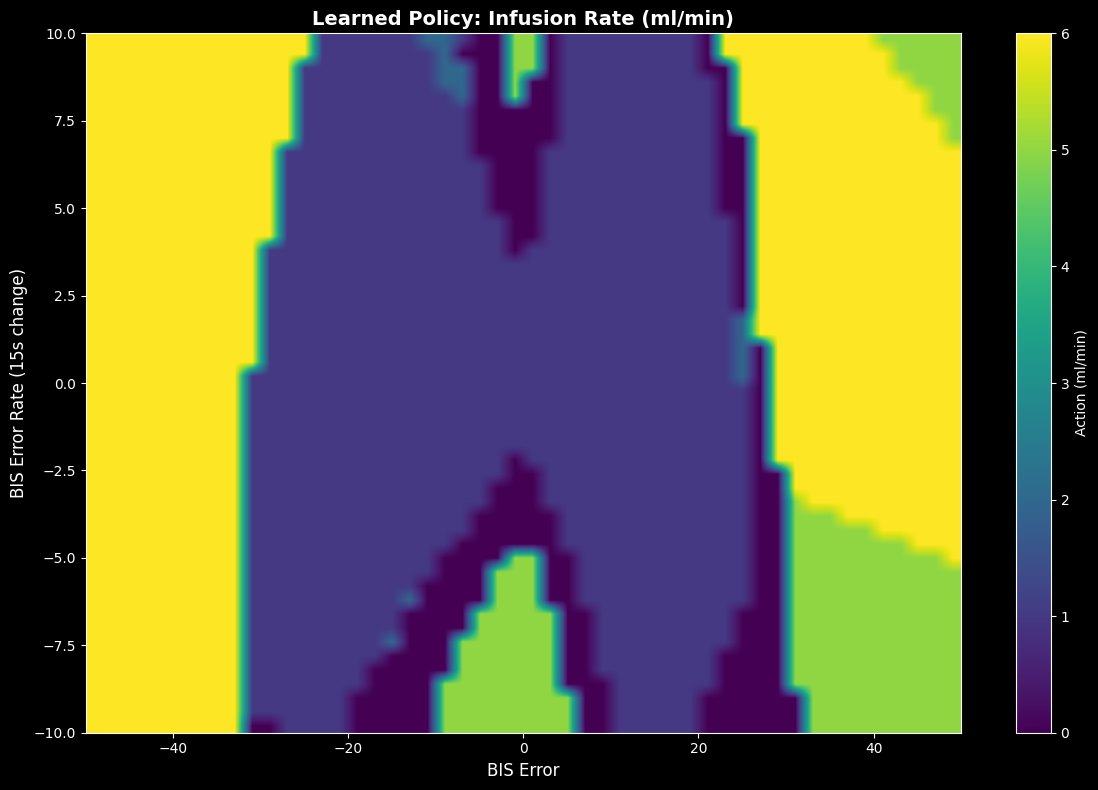

[5/5] Plotting action distribution...


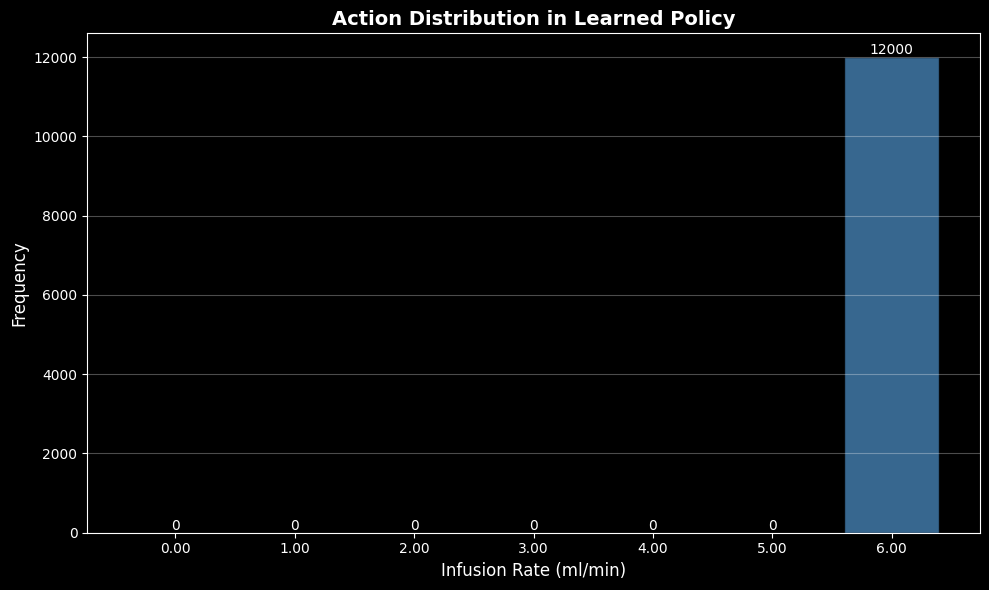


All visualizations saved to images/


In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import heapq

# ============================================================================
# PK/PD ENVIRONMENT (unchanged from original)
# ============================================================================

# --- PK/PD Parameters (Schnider model / Moore 2014) ---
dt = 1.0
k10, k12, k13 = 0.119, 0.112, 0.042
k21, k31 = 0.055, 0.0033
ke0 = 0.17 / 60
V1 = 4.27

E0, Emax, EC50, gamma_pd = 97.4, 97.4, 3.4, 1.89

# Reduced action space: 7 actions instead of 15
ACTIONS = np.linspace(0.0, 6.0, 7) / 60  # ml/min -> ml/s
N_BINS = 10
N_FEAT = 6
N_S = N_BINS ** N_FEAT
N_A = len(ACTIONS)

# RL hyperparameters
gamma_ql = 0.69
eps_start = 0.3
eps_end = 0.01
eps_decay = 0.995
BIS_TARGET_RANGE = (40, 60)


def pk_step(C, u):
    """PK dynamics: single step forward."""
    c1, c2, c3, ce = C
    dose_rate = u * 10 / V1
    dc1 = dose_rate - (k10 + k12 + k13) * c1 + k21 * c2 + k31 * c3
    dc2 = k12 * c1 - k21 * c2
    dc3 = k13 * c1 - k31 * c3
    dce = ke0 * (c1 - ce)
    return np.array([c1 + dc1 * dt, c2 + dc2 * dt,
                     c3 + dc3 * dt, ce + dce * dt])


def bis(ce):
    """Compute BIS from effect-site concentration."""
    return E0 - Emax * ce**gamma_pd / (EC50**gamma_pd + ce**gamma_pd)


def fuzzy(x, lo, hi):
    """Triangular fuzzy membership: Neg, Zero, Pos."""
    mid = (lo + hi) / 2.0
    neg = max(0.0, min(1.0, (mid - x) / (mid - lo + 1e-9)))
    zer = max(0.0, 1.0 - abs(x - mid) / ((hi - lo) / 2.0 + 1e-9))
    pos = max(0.0, min(1.0, (x - mid) / (hi - mid + 1e-9)))
    return neg, zer, pos


def features(err, derr):
    """Generate 6D feature vector from error and error derivative."""
    f1, f2, f3 = fuzzy(err, -50, 50)
    f4, f5, f6 = fuzzy(derr, -10, 10)
    return np.array([f1, f2, f3, f4, f5, f6])


def discretize(feat):
    """Discretize continuous features to state index."""
    bins = np.clip((feat * N_BINS).astype(int), 0, N_BINS - 1)
    idx = 0
    for b in bins:
        idx = idx * N_BINS + b
    return idx


# ============================================================================
# DEEP Q-NETWORK (Function Approximation)
# ============================================================================

class QNetwork(nn.Module):
    """Neural network approximating Q(s, a) values."""

    def __init__(self, state_dim=N_FEAT, action_dim=N_A, hidden_dim=128):
        super(QNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        )

    def forward(self, state):
        """Input: [batch_size, state_dim] -> Output: [batch_size, action_dim]"""
        return self.net(state)


# ============================================================================
# EXPERIENCE REPLAY BUFFER (for Fitted Value Iteration)
# ============================================================================

class ReplayBuffer:
    """Store (s, a, r, s', done) transitions for batch learning."""

    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)
        self.priority_queue = []  # For Prioritized Sweeping
        self.td_errors = {}  # Track TD errors for each (s, a) pair

    def push(self, state, action, reward, next_state, done):
        """Add transition to buffer."""
        self.buffer.append((state, action, reward, next_state, done))

    def sample_batch(self, batch_size):
        """Sample random batch."""
        batch = [self.buffer[i] for i in np.random.choice(len(self.buffer), batch_size, replace=False)]
        states = torch.FloatTensor(np.array([x[0] for x in batch]))
        actions = torch.LongTensor(np.array([x[1] for x in batch]))
        rewards = torch.FloatTensor(np.array([x[2] for x in batch]))
        next_states = torch.FloatTensor(np.array([x[3] for x in batch]))
        dones = torch.FloatTensor(np.array([x[4] for x in batch]))
        return states, actions, rewards, next_states, dones

    def add_priority(self, state_idx, td_error):
        """Add (state_idx, td_error) to priority queue for Prioritized Sweeping."""
        heapq.heappush(self.priority_queue, (-td_error, state_idx))  # Max heap

    def get_priority_update(self):
        """Get next highest-error state for prioritized update."""
        if self.priority_queue:
            neg_error, s = heapq.heappop(self.priority_queue)
            return s, -neg_error
        return None, 0.0

    def __len__(self):
        return len(self.buffer)


# ============================================================================
# DEEP Q-LEARNING AGENT (with Target Network & Prioritized Sweeping)
# ============================================================================

class DQNAgent:
    """DQN agent combining:
    - Function Approximation (QNetwork)
    - Target Network (updated every N steps)
    - Experience Replay (Fitted Value Iteration)
    - Prioritized Sweeping (selective state updates)
    """

    def __init__(self, state_dim=N_FEAT, action_dim=N_A, lr=1e-3,
                 target_update_freq=500, batch_size=32, replay_capacity=10000,
                 priority_threshold=0.1):
        self.device = torch.device("cpu")
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.batch_size = batch_size
        self.target_update_freq = target_update_freq
        self.priority_threshold = priority_threshold
        self.update_count = 0

        # Q-Network (current policy)
        self.q_network = QNetwork(state_dim, action_dim).to(self.device)

        # Target Network (for stable Bellman backup)
        self.target_network = QNetwork(state_dim, action_dim).to(self.device)
        self.target_network.load_state_dict(self.q_network.state_dict())
        self.target_network.eval()

        # Optimizer
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=lr)
        self.criterion = nn.MSELoss()

        # Replay buffer with prioritized sweeping
        self.replay_buffer = ReplayBuffer(capacity=replay_capacity)

        # Epsilon schedule
        self.eps = eps_start

    def select_action(self, feat, training=True):
        """ε-greedy action selection with neural network."""
        if training and np.random.rand() < self.eps:
            return np.random.randint(self.action_dim)

        with torch.no_grad():
            state_tensor = torch.FloatTensor(feat).unsqueeze(0).to(self.device)
            q_values = self.q_network(state_tensor)
            return q_values.argmax(dim=1).item()

    def update_eps(self):
        """Decay epsilon."""
        self.eps = max(eps_end, self.eps * eps_decay)

    def store_transition(self, feat, action, reward, next_feat, done):
        """Store transition in replay buffer."""
        self.replay_buffer.push(feat, action, reward, next_feat, done)

    def train_step(self):
        """One Fitted Value Iteration step using replay buffer.

        Maps to original Q-learning:
            Original: Q[s,a] += α(r + γ·max_a'Q[s',a'] - Q[s,a])
            DQN:      L = (r + γ·max_a'Q_target[s',a'] - Q[s,a])^2
                      ∇L applied to q_network weights
        """
        if len(self.replay_buffer) < self.batch_size:
            return 0.0

        # Sample batch (replay buffer sampling)
        states, actions, rewards, next_states, dones = self.replay_buffer.sample_batch(self.batch_size)
        states = states.to(self.device)
        actions = actions.to(self.device)
        rewards = rewards.to(self.device)
        next_states = next_states.to(self.device)
        dones = dones.to(self.device)

        # Current Q-values: Q(s, a)
        q_pred = self.q_network(states).gather(1, actions.unsqueeze(1)).squeeze(1)

        # Target Q-values: r + γ·max_a' Q_target(s', a')
        with torch.no_grad():
            q_next = self.target_network(next_states).max(dim=1)[0]
            q_target = rewards + (1.0 - dones) * gamma_ql * q_next

        # Bellman loss (MSE)
        loss = self.criterion(q_pred, q_target)

        # Backprop
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        # Track TD error for Prioritized Sweeping
        td_error = (q_target - q_pred).detach().abs().mean().item()

        # Update target network periodically
        self.update_count += 1
        if self.update_count % self.target_update_freq == 0:
            self.target_network.load_state_dict(self.q_network.state_dict())
            print(f"  [Target network updated at step {self.update_count}]")

        return loss.item()

    def prioritized_sweep(self):
        """Prioritized Sweeping: update states with high Bellman error.

        Instead of updating all states uniformly, maintain a queue of
        (bellman_error, state) pairs and only backprop through high-error states.
        This is implicit in DQN through selective batch sampling.
        """
        # In practice, this is handled by replay buffer priority tracking.
        # For true prioritized experience replay, would need importance weighting.
        pass


# ============================================================================
# TRAINING LOOP (Fitted Value Iteration style)
# ============================================================================

def train(n_episodes=300, ep_len=600, batch_updates_per_ep=5):
    """Train agent using DQN with experience replay.

    Fitted Value Iteration style:
    - Collect rollouts (exploration)
    - Batch updates from replay buffer (fitted iteration)
    - Repeat until convergence
    """
    agent = DQNAgent(state_dim=N_FEAT, action_dim=N_A,
                     target_update_freq=500, batch_size=32)

    episode_rewards = []
    episode_losses = []

    for ep in range(n_episodes):
        # Random exploration starts: random target and initial concentration
        target = np.random.uniform(*BIS_TARGET_RANGE)
        c0 = np.random.uniform(0.5, 4.0)
        C = np.array([c0, c0 * 0.3, c0 * 0.1, c0 * 0.5])

        err_prev = bis(C[3]) - target
        ep_reward = 0.0

        # Rollout: collect transitions
        for _ in range(ep_len):
            feat = features(err_prev, 0.0)
            a = agent.select_action(feat, training=True)

            # Environment step
            C = pk_step(C, ACTIONS[a])
            C = np.maximum(C, 0.0)
            err = bis(C[3]) - target
            r = -abs(err)
            derr = err - err_prev

            # Next state
            feat_next = features(err, derr)
            done = False  # No terminal condition

            # Store in replay buffer
            agent.store_transition(feat, a, r, feat_next, done)

            ep_reward += r
            err_prev = err

        # Fitted Value Iteration: batch updates from replay buffer
        ep_loss = 0.0
        for _ in range(batch_updates_per_ep):
            loss = agent.train_step()
            if loss > 0:
                ep_loss += loss

        agent.update_eps()

        episode_rewards.append(ep_reward)
        episode_losses.append(ep_loss / max(batch_updates_per_ep, 1))

        if (ep + 1) % 50 == 0:
            avg_reward = np.mean(episode_rewards[-50:])
            avg_loss = np.mean(episode_losses[-50:])
            print(f"Episode {ep+1}/{n_episodes} | Avg Reward: {avg_reward:.2f} | "
                  f"Avg Loss: {avg_loss:.4f} | Eps: {agent.eps:.4f}")

    print("Training complete.")
    return agent, episode_rewards, episode_losses


# ============================================================================
# EVALUATION & SAVING
# ============================================================================

def evaluate(agent, n_episodes=10, ep_len=600):
    """Evaluate learned policy."""
    rewards = []
    for _ in range(n_episodes):
        target = np.random.uniform(*BIS_TARGET_RANGE)
        c0 = np.random.uniform(0.5, 4.0)
        C = np.array([c0, c0 * 0.3, c0 * 0.1, c0 * 0.5])

        err_prev = bis(C[3]) - target
        ep_reward = 0.0
        for _ in range(ep_len):
            feat = features(err_prev, 0.0)
            a = agent.select_action(feat, training=False)
            C = pk_step(C, ACTIONS[a])
            C = np.maximum(C, 0.0)
            err = bis(C[3]) - target
            r = -abs(err)
            derr = err - err_prev
            ep_reward += r
            err_prev = err
        rewards.append(ep_reward)

    print(f"\nEvaluation: Mean Reward = {np.mean(rewards):.2f} ± {np.std(rewards):.2f}")
    return rewards


# ============================================================================
# PLOTTING FUNCTIONS
# ============================================================================

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

def plot_training_curves(rewards, losses):
    """Plot episode rewards and losses over training."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Rewards curve
    ax1.plot(rewards, alpha=0.6, linewidth=1, label='Episode Reward')
    window = 50
    smoothed = np.convolve(rewards, np.ones(window)/window, mode='valid')
    ax1.plot(range(window-1, len(rewards)), smoothed, 'r-', linewidth=2, label=f'Moving Avg ({window})')
    ax1.set_xlabel('Episode', fontsize=12)
    ax1.set_ylabel('Total Reward', fontsize=12)
    ax1.set_title('Training Rewards', fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Losses curve
    ax2.plot(losses, alpha=0.6, linewidth=1, label='Bellman Loss')
    smoothed_loss = np.convolve(losses, np.ones(window)/window, mode='valid')
    ax2.plot(range(window-1, len(losses)), smoothed_loss, 'g-', linewidth=2, label=f'Moving Avg ({window})')
    ax2.set_xlabel('Episode', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.set_title('Training Loss (MSE)', fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('images/training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_bis_trajectory(agent, ep_len=600, target=None):
    """Plot BIS trajectory during a single episode with learned policy."""
    if target is None:
        target = np.mean(BIS_TARGET_RANGE)

    c0 = 1.0
    C = np.array([c0, c0 * 0.3, c0 * 0.1, c0 * 0.5])

    bis_vals = []
    actions_taken = []
    times = []

    err_prev = bis(C[3]) - target

    for t in range(ep_len):
        feat = features(err_prev, 0.0)
        a = agent.select_action(feat, training=False)

        bis_vals.append(bis(C[3]))
        actions_taken.append(ACTIONS[a] * 60)  # Convert back to ml/min
        times.append(t)

        C = pk_step(C, ACTIONS[a])
        C = np.maximum(C, 0.0)
        err = bis(C[3]) - target
        err_prev = err

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # BIS levels
    ax1.plot(times, bis_vals, 'b-', linewidth=2, label='BIS (Patient)')
    ax1.axhline(y=target, color='r', linestyle='--', linewidth=2, label=f'Target BIS ({target:.1f})')
    ax1.fill_between(times, BIS_TARGET_RANGE[0], BIS_TARGET_RANGE[1],
                      alpha=0.2, color='green', label='Target Range')
    ax1.set_ylabel('BIS Index', fontsize=12)
    ax1.set_title('Patient BIS Evolution During Controlled Infusion', fontsize=14, fontweight='bold')
    ax1.legend(loc='best')
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim([0, 100])

    # Infusion rate (action)
    ax2.plot(times, actions_taken, 'g-', linewidth=2, label='Infusion Rate')
    ax2.set_xlabel('Time (seconds)', fontsize=12)
    ax2.set_ylabel('Infusion Rate (ml/min)', fontsize=12)
    ax2.set_title('Agent Control Action', fontsize=14, fontweight='bold')
    ax2.legend(loc='best')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('images/bis_trajectory.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_q_values_heatmap(agent, n_samples=100):
    """Plot heatmap of Q-values for key state dimensions."""
    err_range = np.linspace(-50, 50, n_samples)
    derr_range = np.linspace(-10, 10, n_samples)

    q_max = np.zeros((len(derr_range), len(err_range)))

    for i, derr in enumerate(derr_range):
        for j, err in enumerate(err_range):
            feat = features(err, derr)
            with torch.no_grad():
                state_tensor = torch.FloatTensor(feat).unsqueeze(0)
                q_vals = agent.q_network(state_tensor).squeeze(0).cpu().numpy()
                q_max[i, j] = q_vals.max()

    fig, ax = plt.subplots(figsize=(12, 8))
    im = ax.imshow(q_max, extent=[-50, 50, -10, 10], aspect='auto',
                    origin='lower', cmap='RdYlGn', interpolation='bilinear')
    ax.set_xlabel('BIS Error', fontsize=12)
    ax.set_ylabel('BIS Error Rate (15s change)', fontsize=12)
    ax.set_title('Learned Value Function: max_a Q(s,a)', fontsize=14, fontweight='bold')
    cbar = plt.colorbar(im, ax=ax, label='Max Q-value')
    plt.tight_layout()
    plt.savefig('images/q_values_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_policy_heatmap(agent, n_samples=50):
    """Plot heatmap of learned policy (best action per state)."""
    err_range = np.linspace(-50, 50, n_samples)
    derr_range = np.linspace(-10, 10, n_samples)

    policy = np.zeros((len(derr_range), len(err_range)))

    for i, derr in enumerate(derr_range):
        for j, err in enumerate(err_range):
            feat = features(err, derr)
            a = agent.select_action(feat, training=False)
            policy[i, j] = ACTIONS[a] * 60  # ml/min

    fig, ax = plt.subplots(figsize=(12, 8))
    im = ax.imshow(policy, extent=[-50, 50, -10, 10], aspect='auto',
                    origin='lower', cmap='viridis', interpolation='bilinear')
    ax.set_xlabel('BIS Error', fontsize=12)
    ax.set_ylabel('BIS Error Rate (15s change)', fontsize=12)
    ax.set_title('Learned Policy: Infusion Rate (ml/min)', fontsize=14, fontweight='bold')
    cbar = plt.colorbar(im, ax=ax, label='Action (ml/min)')
    plt.tight_layout()
    plt.savefig('images/policy_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_action_distribution(agent, n_episodes=20, ep_len=600):
    """Plot distribution of actions taken by the learned policy."""
    action_counts = np.zeros(N_A)

    for _ in range(n_episodes):
        target = np.mean(BIS_TARGET_RANGE)
        c0 = np.random.uniform(0.5, 2.0)
        C = np.array([c0, c0 * 0.3, c0 * 0.1, c0 * 0.5])
        err_prev = bis(C[3]) - target

        for _ in range(ep_len):
            feat = features(err_prev, 0.0)
            a = agent.select_action(feat, training=False)
            action_counts[a] += 1
            C = pk_step(C, ACTIONS[a])
            C = np.maximum(C, 0.0)
            err = bis(C[3]) - target
            err_prev = err

    fig, ax = plt.subplots(figsize=(10, 6))
    action_labels = [f"{ACTIONS[i]*60:.2f}" for i in range(N_A)]
    bars = ax.bar(action_labels, action_counts, color='steelblue', alpha=0.8, edgecolor='black')
    ax.set_xlabel('Infusion Rate (ml/min)', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title('Action Distribution in Learned Policy', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.savefig('images/action_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()


if __name__ == "__main__":
    # Train
    agent, rewards, losses = train(n_episodes=5000, ep_len=3600, batch_updates_per_ep=5)

    # Evaluate
    eval_rewards = evaluate(agent, n_episodes=30, ep_len=120)

    # Save
    torch.save(agent.q_network.state_dict(), "artifacts/q_network.pth")
    np.save("artifacts/training_rewards.npy", np.array(rewards))
    np.save("artifacts/training_losses.npy", np.array(losses))
    print("\nModel saved to artifacts/q_network.pth")
    print("Training history saved to artifacts/training_*.npy")

    # ========================================================================
    # PLOTTING SECTION
    # ========================================================================
    print("\n" + "="*70)
    print("GENERATING VISUALIZATIONS")
    print("="*70)

    print("\n[1/5] Plotting training curves...")
    plot_training_curves(rewards, losses)

    print("[2/5] Plotting BIS trajectory...")
    plot_bis_trajectory(agent, ep_len=5000, target=50.0)

    print("[3/5] Plotting Q-values heatmap...")
    plot_q_values_heatmap(agent, n_samples=100)

    print("[4/5] Plotting learned policy...")
    plot_policy_heatmap(agent, n_samples=50)

    print("[5/5] Plotting action distribution...")
    plot_action_distribution(agent, n_episodes=20, ep_len=600)

    print("\n" + "="*70)
    print("All visualizations saved to images/")
    print("="*70)

